In [1]:
from google.cloud import bigquery
from google.oauth2 import service_account
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV, RepeatedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt
import numpy as np

Import des librairies nécessaires

In [2]:
KEY_PATH = r"C:\Users\Administrateur\Documents\Formation Data Analyste\Projet final\urbanmove-489008-6c0d2b1a62ad.json"
PROJECT_ID = "urbanmove-489008"

credentials = service_account.Credentials.from_service_account_file(
KEY_PATH,
scopes=["https://www.googleapis.com/auth/cloud-platform"]
)

client = bigquery.Client(credentials=credentials, project=PROJECT_ID)
print("Connexion BigQuery OK")

Connexion BigQuery OK


Connexion à BigQuery

In [3]:
QUERY = """
SELECT *
FROM urbanmove-489008.UrbanMove.table_previsions_fer
"""

df = client.query(QUERY).to_dataframe()
print(f"{len(df):,} lignes chargées — {df.shape[1]} colonnes")
df.head()

29,971 lignes chargées — 15 colonnes


,date_jour,annee,mois,jour,jour_semaine,id_ligne,mode_transport,precipitation,vent,neige,temperature,meteo_defavorable,retard_moyen_minutes,accessibilite,air_conditionne
0,2024-01-01,2024,1,1,Monday,C01381,metro,2.9,34.4,0.0,8.0,False,49.19,false,true
1,2024-01-01,2024,1,1,Monday,C01857,rail,2.9,34.4,0.0,8.0,False,80.26,unknown,true
2,2024-01-05,2024,1,5,Friday,C01738,rail,0.0,25.2,0.0,6.9,False,69.90,false,true
3,2024-01-06,2024,1,6,Saturday,C01387,metro,1.7,22.2,0.0,5.1,False,37.18,false,false
4,2024-01-06,2024,1,6,Saturday,C01386,metro,1.7,22.2,0.0,5.1,False,37.12,false,false


Import des données et création du dataframe

In [4]:
df_model = df.copy()
df_model = df_model.drop(columns = ['date_jour'])
df_model["meteo_defavorable"] = df_model["meteo_defavorable"].astype(int)

categorical_columns = ['jour_semaine', 'id_ligne', 'mode_transport', 'accessibilite', 'air_conditionne']
encoder = LabelEncoder()
for col in categorical_columns:
    df_model[col] = encoder.fit_transform(df_model[col])

df_model.head()

,annee,mois,jour,jour_semaine,id_ligne,mode_transport,precipitation,vent,neige,temperature,meteo_defavorable,retard_moyen_minutes,accessibilite,air_conditionne
0,2024,1,1,1,10,0,2.9,34.4,0.0,8.0,0,49.19,0,2
1,2024,1,1,1,34,1,2.9,34.4,0.0,8.0,0,80.26,2,2
2,2024,1,5,0,23,1,0.0,25.2,0.0,6.9,0,69.90,0,2
3,2024,1,6,2,15,0,1.7,22.2,0.0,5.1,0,37.18,0,0
4,2024,1,6,2,14,0,1.7,22.2,0.0,5.1,0,37.12,0,0


Préparation des données pour la forêt aléatoire

In [5]:
X = df_model.drop(columns = ['retard_moyen_minutes'])
y = df_model['retard_moyen_minutes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Ensemble d'entraînement : {X_train.shape}, Ensemble de test : {X_test.shape}")

Ensemble d'entraînement : (23976, 13), Ensemble de test : (5995, 13)


Division des données pour l'entrainement

In [6]:
# Définition de la grille de paramètres
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4, 8]
}

rf = RandomForestRegressor()

# Mise en place du test (n_iter=10 testera 10 combinaisons au hasard)
# cv=3 signifie une validation croisée en 3 étapes
random_search = RandomizedSearchCV(
    estimator=rf, 
    param_distributions=param_dist, 
    n_iter=10, 
    cv=3, 
    scoring='neg_mean_absolute_error', 
    n_jobs=-1, # Utilise tous les processeurs de votre instance GCP
    verbose=2,
    random_state = 42
)

# Exécution sur un échantillon pour gagner du temps au début
# (Prendre 100k lignes pour le réglage est souvent suffisant)
random_search.fit(X, y)

print(f"Meilleurs paramètres : {random_search.best_params_}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Meilleurs paramètres : {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 10}


Test pour définir les meilleurs paramètres pour la forêt aléatoire

In [7]:
# Création et entraînement de la forêt aléatoire
regressor = RandomForestRegressor(n_estimators = 200, min_samples_split = 2, min_samples_leaf = 4, max_depth = 10, random_state=42)
regressor.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Création et entrainement de la forêt aléatoire

In [8]:
# Prédictions sur l'ensemble de test
y_pred = regressor.predict(X_test)
# Calcul des métriques
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Erreur Quadratique Moyenne (MSE) : {mse:.2f}")
print(f"Coefficient de Détermination (R²) : {r2:.2f}")

Erreur Quadratique Moyenne (MSE) : 3.45
Coefficient de Détermination (R²) : 0.99


Prédiction et évaluation (score) de notre modèle

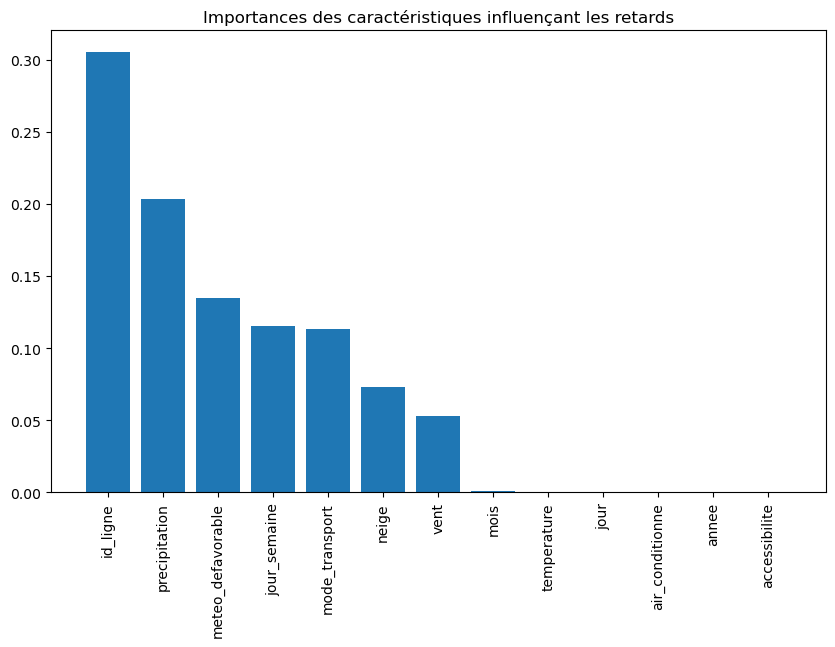

In [9]:
# Importances des variables
importances = regressor.feature_importances_
indices = np.argsort(importances)[::-1]
# Tracer les importances
plt.figure(figsize=(10, 6))
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.title("Importances des caractéristiques influençant les retards")
plt.show()

Visualisation des variables classées par ordre d'influence sur les retards

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:  3.9min
[Parallel(n_jobs=4)]: Done  50 out of  50 | elapsed:  4.3min finished


  RÉSULTATS REPEATED K-FOLDS (5 splits × 10 répétitions)

Métrique                      Mean       Std       Min       Max
-------------------------------------------------------
R² TEST                     0.9939    0.0002    0.9931    0.9943
R² TRAIN                    0.9947    0.0001    0.9946    0.9949
MAE TEST                    1.3096    0.0156    1.2767    1.3503
MSE TEST                    3.4045    0.1368    3.1285    3.7944

Gap Train/Test R² : 0.0009  →  ✅ Pas d'overfitting significatif


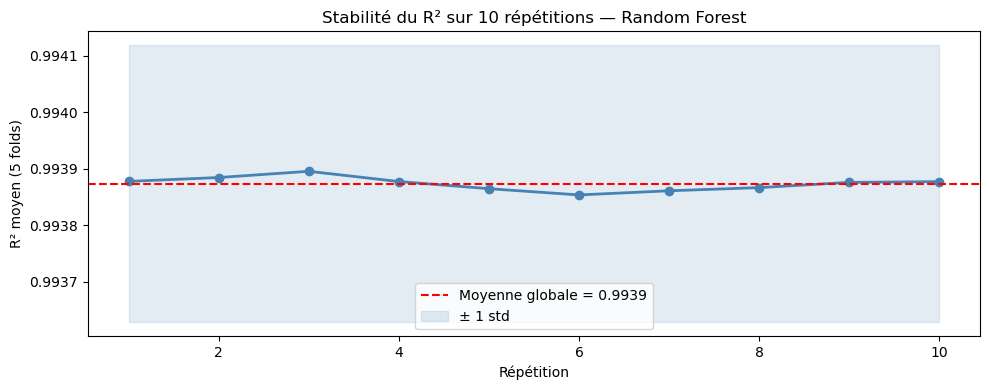

In [10]:
rkf = RepeatedKFold(n_splits=5, n_repeats=10, random_state=42)

cv_results = cross_validate(
    estimator=regressor,
    X=X,
    y=y,
    cv=rkf,
    scoring={
        'r2':  'r2',
        'mae': 'neg_mean_absolute_error',
        'mse': 'neg_mean_squared_error'
    },
    return_train_score=True,
    n_jobs=4,
    verbose=1
)

r2_test  = cv_results['test_r2']
r2_train = cv_results['train_r2']
mae_test = -cv_results['test_mae']
mse_test = -cv_results['test_mse']

print("=" * 55)
# ✏️ Mise à jour du titre
print("  RÉSULTATS REPEATED K-FOLDS (5 splits × 10 répétitions)")
print("=" * 55)
print(f"\n{'Métrique':<25} {'Mean':>8}  {'Std':>8}  {'Min':>8}  {'Max':>8}")
print("-" * 55)
print(f"{'R² TEST':<25} {r2_test.mean():>8.4f}  {r2_test.std():>8.4f}  {r2_test.min():>8.4f}  {r2_test.max():>8.4f}")
print(f"{'R² TRAIN':<25} {r2_train.mean():>8.4f}  {r2_train.std():>8.4f}  {r2_train.min():>8.4f}  {r2_train.max():>8.4f}")
print(f"{'MAE TEST':<25} {mae_test.mean():>8.4f}  {mae_test.std():>8.4f}  {mae_test.min():>8.4f}  {mae_test.max():>8.4f}")
print(f"{'MSE TEST':<25} {mse_test.mean():>8.4f}  {mse_test.std():>8.4f}  {mse_test.min():>8.4f}  {mse_test.max():>8.4f}")

gap = r2_train.mean() - r2_test.mean()
print(f"\nGap Train/Test R² : {gap:.4f}", end="  →  ")
if gap > 0.05:
    print("⚠️  Possible overfitting détecté")
else:
    print("✅ Pas d'overfitting significatif")


r2_par_rep = r2_test.reshape(10, 5).mean(axis=1)

plt.figure(figsize=(10, 4))
plt.plot(range(1, 11), r2_par_rep, marker='o', linewidth=2, color='steelblue')
plt.axhline(r2_test.mean(), color='red', linestyle='--', label=f'Moyenne globale = {r2_test.mean():.4f}')
plt.fill_between(range(1, 11),
                 r2_test.mean() - r2_test.std(),
                 r2_test.mean() + r2_test.std(),
                 alpha=0.15, color='steelblue', label='± 1 std')
plt.xlabel("Répétition")
plt.ylabel("R² moyen (5 folds)")
plt.title("Stabilité du R² sur 10 répétitions — Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

Validation croisée répétée 10 fois pour vérifier la fiabilité du modèle

In [11]:
df_model_2 = df.copy()
df_model_2 = df_model_2.drop(columns = ['date_jour'])
df_model_2["meteo_defavorable"] = df_model_2["meteo_defavorable"].astype(int)
df_model_2['annee'] = df_model_2['annee'].astype(int)
df_model_2['mois'] = df_model_2['mois'].astype(int)
df_model_2['jour'] = df_model_2['jour'].astype(int)

# Colonnes numériques et catégoriques
numerical_columns = ['temperature', 'mois', 'annee', 'jour', 'precipitation', 'vent', 'neige', 'meteo_defavorable']
categorical_columns = ['id_ligne', 'mode_transport', 'accessibilite', 'air_conditionne', 'jour_semaine']
# Séparer les caractéristiques et la cible
X = df_model_2.drop(columns = ['retard_moyen_minutes'])
y = df_model_2['retard_moyen_minutes']
# Prétraiter les données
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns),  # Normalisation des numériques
        ("cat", OneHotEncoder(), categorical_columns),  # Encodage des catégories
    ]
)
# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Appliquer le préprocesseur
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)
# Vérification
print(f"Dimensions après prétraitement - Entraînement : {X_train_transformed.shape}")

Dimensions après prétraitement - Entraînement : (23976, 64)


Préparation et division des données pour le réseau de neurones

In [12]:
# Construire le modèle
model = Sequential([
    Input(shape=(X_train_transformed.shape[1],)),
    Dense(64, activation="relu"),
    Dropout(0.3),  # Dropout de 30%
    Dense(32, activation='relu'),
    Dropout(0.2),  # Dropout de 20%
    Dense(16, activation='relu'),
    Dense(1, activation="linear")  # Couche de sortie
])
# Résumé du modèle
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,785 (26.50 KB)

 Trainable params: 6,785 (26.50 KB)

 Non-trainable params: 0 (0.00 B)

Construction du modèle de réseau de neurones

In [13]:
# Compiler le modèle
model.compile(
    optimizer='adam', 
    loss='mean_squared_error',  # Perte pour la régression
    metrics=['mean_absolute_error']  # MAE pour l'évaluation
)

Compilation du modèle

In [14]:
history = model.fit(
    X_train_transformed, y_train,
    epochs=100,           
    batch_size=64,     
    validation_split=0.2,
    verbose=2
)

Epoch 1/100
300/300 - 3s - 11ms/step - loss: 1176.5347 - mean_absolute_error: 24.0465 - val_loss: 139.3602 - val_mean_absolute_error: 7.6155
Epoch 2/100
300/300 - 1s - 3ms/step - loss: 208.1349 - mean_absolute_error: 10.2568 - val_loss: 129.6939 - val_mean_absolute_error: 7.3929
Epoch 3/100
300/300 - 1s - 3ms/step - loss: 189.5863 - mean_absolute_error: 9.8223 - val_loss: 119.3631 - val_mean_absolute_error: 7.1420
Epoch 4/100
300/300 - 1s - 3ms/step - loss: 185.0727 - mean_absolute_error: 9.6222 - val_loss: 111.1477 - val_mean_absolute_error: 6.9475
Epoch 5/100
300/300 - 1s - 3ms/step - loss: 178.0256 - mean_absolute_error: 9.4870 - val_loss: 109.1667 - val_mean_absolute_error: 6.8704
Epoch 6/100
300/300 - 1s - 3ms/step - loss: 175.8745 - mean_absolute_error: 9.3688 - val_loss: 104.1456 - val_mean_absolute_error: 6.9517
Epoch 7/100
300/300 - 1s - 3ms/step - loss: 169.5420 - mean_absolute_error: 9.2338 - val_loss: 103.2637 - val_mean_absolute_error: 6.7727
Epoch 8/100
300/300 - 1s - 4ms

Entrainement du modèle

In [15]:
# Évaluer le modèle
loss, mae = model.evaluate(X_test_transformed, y_test)
print(f"Perte (MSE) sur le test : {loss:.2f}")
print(f"Erreur absolue moyenne (MAE) : {mae:.2f}")

y_pred = model.predict(X_test_transformed)
r2 = r2_score(y_test, y_pred)
print(f"R² : {r2:.2f}")

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 42.6774 - mean_absolute_error: 4.7699
Perte (MSE) sur le test : 42.68
Erreur absolue moyenne (MAE) : 4.77
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
R² : 0.92


Evaluation (score) du modèle

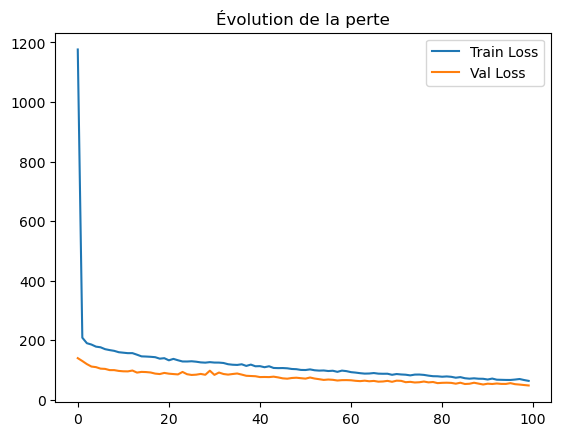

In [16]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Évolution de la perte')
plt.legend()

Visualisation de l'évolution de la perte

Text(0.5, 1.0, 'Comparaison Réel vs Prédit')

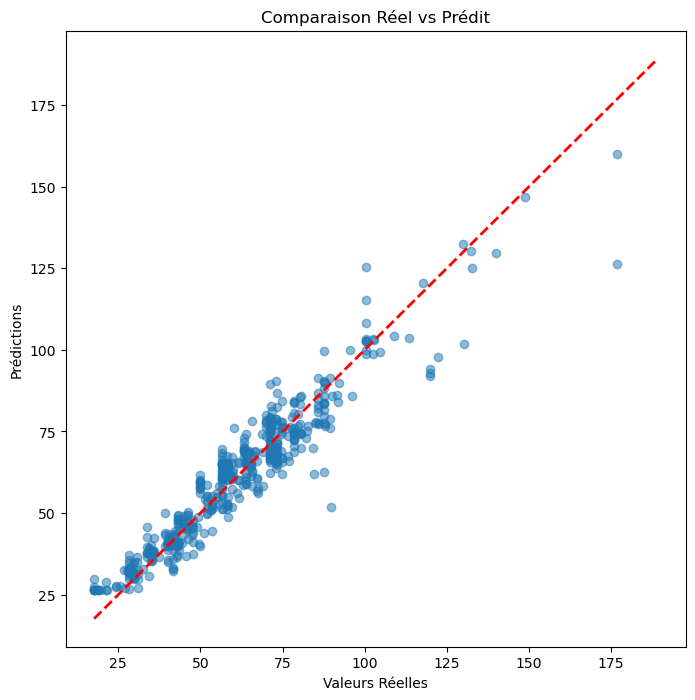

In [17]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test[:500], y_pred[:500], alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valeurs Réelles')
plt.ylabel('Prédictions')
plt.title('Comparaison Réel vs Prédit')

Visualisation comparative entre le réel et la prédiction

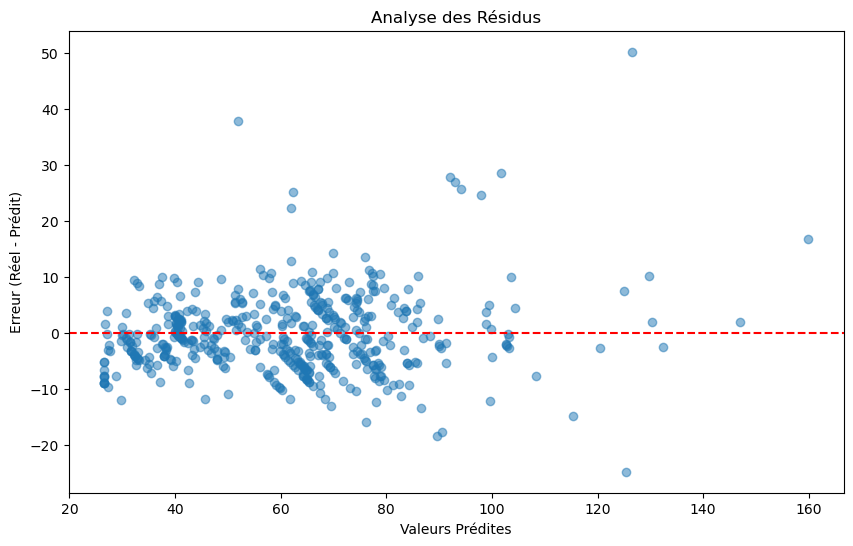

In [18]:
residus = y_test.values.flatten() - y_pred.flatten()

plt.figure(figsize=(10, 6))
plt.scatter(y_pred[:500], residus[:500], alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Valeurs Prédites')
plt.ylabel('Erreur (Réel - Prédit)')
plt.title('Analyse des Résidus')
plt.show()

Visualisation des résidus

In [19]:
df_prev = pd.read_csv('Conditions fer demain.csv')

df_model_prev = df_prev.copy()
categorical_columns_prev = ['id_ligne', 'mode_transport', 'accessibilite', 'air_conditionne']
encoder = LabelEncoder()
for col in categorical_columns:
    df_model_prev[col] = encoder.fit_transform(df_model_prev[col])

df_model_prev.head()

,annee,mois,jour,jour_semaine,id_ligne,mode_transport,precipitation,vent,neige,temperature,meteo_defavorable,accessibilite,air_conditionne
0,2026,3,13,0,32,1,2.9,25.0,0.0,8.5,0,2,1
1,2026,3,13,0,33,1,2.9,25.0,0.0,8.5,0,2,1
2,2026,3,13,0,22,1,2.9,25.0,0.0,8.5,0,0,1
3,2026,3,13,0,8,0,2.9,25.0,0.0,8.5,0,0,1
4,2026,3,13,0,38,1,2.9,25.0,0.0,8.5,0,2,1


Import données de demain (vendredi 13/03/2026) pour la prévision

In [21]:
df_prev['retard_prevu'] = regressor.predict(df_model_prev)

# Création de la table classée par retard
table_classement = df_prev[['id_ligne', 'mode_transport', 'retard_prevu']].sort_values(by='retard_prevu', ascending=False)
table_classement['retard_prevu'] = table_classement['retard_prevu'].round(2)

print("Top 10 des lignes les plus impactées :")
print(table_classement.head(10))

Top 10 des lignes les plus impactées :
   id_ligne mode_transport  retard_prevu
29   C02711           rail         88.32
39   C02375           rail         88.32
10   C01742           rail         87.85
6    C01746           rail         87.84
31   C01863           rail         87.84
5    C01743           rail         87.84
0    C01747           rail         87.83
1    C01748           rail         87.83
33   C01744           rail         87.82
9    C01745           rail         87.82


Traitement des données via la forêt aléatoire et sortie du top 10 des lignes qui cumuleraient le plus de retard